3. Train a DCGAN to tackle the image dataset of your choice, and use it to generate images. Add experience replay and see if this helps.

4. Train a diffusion model on your preferred image dataset (e.g., torchvision.datasets.Flowers102), and generate nice images. Next, add the image class as an extra input to the model, and retrain it: you should now be able to control the class of the generated image.


experience replay consists of storing the images produced by the generator at each iteration in a replay buffer (gradually dropping older generated images) and training the discriminator using real images plus fake images drawn from this buffer (rather than just fake images produced by the current generator). 

DCGAN - deep convolutional GAN (see authors notebook)

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
import gc
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

device = 'cuda'

gc.collect()
torch.cuda.empty_cache()

In [213]:
def train_gan(generator, discriminator, train_loader, codings_dim, n_epochs=20, g_lr=1e-3, d_lr=5e-4, replay_buffer=False):
    criterion = nn.BCELoss()
    generator_optim = torch.optim.NAdam(params=generator.parameters(), lr=g_lr)
    discriminator_optim = torch.optim.NAdam(params=discriminator.parameters(), lr=d_lr)
    replay_buff = None
    for epoch in range(n_epochs):
        generator_total_loss = 0
        discriminator_total_loss = 0
        for X_batch, _ in train_loader:
            X_batch = X_batch.to(device)
            pred_real = discriminator(X_batch)
            batch_size = pred_real.size(0)
            ones = torch.ones(batch_size, 1, device=device)
            real_loss = criterion(pred_real, ones)
            codings = torch.randn(batch_size, codings_dim, device=device)
            fake_images = generator(codings).detach()
            
            if replay_buffer:
                if replay_buff == None:
                    replay_buff = fake_images.clone()
                else:
                    replay_buff = torch.cat([replay_buff, fake_images], dim=0)
                    if replay_buff.size(0) >= batch_size*10:
                        replay_buff = replay_buff[batch_size:, :, :, :]
                    
                    if epoch > 3:
                        replaced_num = torch.randint(int(batch_size*0.1), int(batch_size*0.5), size=[1]).item()
                        rand_indices = torch.randint(0, replay_buff.size(0)-batch_size, (replaced_num,))
                        fake_images[:replaced_num] = replay_buff[rand_indices]
            
            
            fake_pred = discriminator(fake_images)
            zeros = torch.zeros(batch_size, 1, device=device)
            fake_loss = criterion(fake_pred, zeros)
            discriminator_loss = real_loss + fake_loss
            discriminator_total_loss += discriminator_loss.item()
            discriminator_optim.zero_grad()
            discriminator_loss.backward()
            discriminator_optim.step()
            
            
            codings = torch.randn(batch_size, codings_dim, device=device)
            gen_images = generator(codings)
            for p in discriminator.parameters():
                p.requires_grad = False
            fake_preds = discriminator(gen_images)
            generator_loss = criterion(fake_preds, ones)
            generator_total_loss += generator_loss.item()
            generator_optim.zero_grad()
            generator_loss.backward()
            generator_optim.step()
            for p in discriminator.parameters():
                p.requires_grad = True
        
        print(f'\rEpoch: {epoch}\tGenerator loss: {generator_total_loss/len(train_loader)}\tDiscriminator loss: {discriminator_total_loss/len(train_loader)}', end="")

In [3]:
ToTensor = T.Compose([T.ToImage(), T.ToDtype(dtype=torch.float32, scale=True)])

cifar10 = torchvision.datasets.CIFAR10(root='./datas', transform=ToTensor, download=False)
cifar10_train, cifar10_valid = torch.utils.data.random_split(cifar10, [45000, 5000])

train_loader = DataLoader(cifar10_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(cifar10_valid, batch_size=32)

In [12]:
codings_dim = 256

dc_generator = nn.Sequential(nn.Linear(codings_dim, 512*2*2), nn.Unflatten(dim=1, unflattened_size=(512, 2, 2)), nn.BatchNorm2d(512), #[512x2x2]
                             nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(256), #[256x4x4]
                              nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(128), #[128x8x8]
                               nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(64), #[64x16x16]
                                nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid()).to(device) #[3x32x32]

dc_discriminator = nn.Sequential(nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[32x16x16]
                                 nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[64x8x8]
                                 nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[128x4x4]
                                 nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[256x2x2]
                                 nn.Flatten(), nn.Linear(256*2*2, 1), nn.Sigmoid()).to(device)

In [13]:
train_gan(dc_generator, dc_discriminator, train_loader, codings_dim)

Epoch: 0	Generator loss: 0.8908643036360595	Discriminator loss: 1.2957258501540878
Epoch: 1	Generator loss: 1.1497821699200408	Discriminator loss: 1.14655498845745
Epoch: 2	Generator loss: 1.1076578944180142	Discriminator loss: 1.1534205720029829
Epoch: 3	Generator loss: 1.2005277418802203	Discriminator loss: 1.104714753954819
Epoch: 4	Generator loss: 1.2296419629579582	Discriminator loss: 1.0801362987096714
Epoch: 5	Generator loss: 1.2570778241204978	Discriminator loss: 1.0659123119006533
Epoch: 6	Generator loss: 1.3045259590003198	Discriminator loss: 1.0482900230784575
Epoch: 7	Generator loss: 1.2163618956378104	Discriminator loss: 1.0935543666685736
Epoch: 8	Generator loss: 1.1962036543817662	Discriminator loss: 1.1098246090617176
Epoch: 9	Generator loss: 1.1660220305717999	Discriminator loss: 1.1067150225856242
Epoch: 10	Generator loss: 1.138955974672056	Discriminator loss: 1.1228195184837781
Epoch: 11	Generator loss: 1.1394223333167623	Discriminator loss: 1.1185655025361527
Epoch:

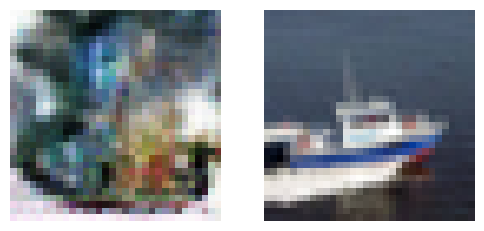

In [ ]:
def gen_comparison(model):
    model.eval()
    with torch.no_grad():
        codings = torch.randn(1, 256, device=device)
        image = model(codings)
        
    image = image.permute(0, 2, 3, 1)
    image = image.cpu()

    fig = plt.figure(figsize=(6, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image.view(32, 32, 3))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cifar10_valid[torch.randint(0, 5000, size=[1]).item()][0].permute(1, 2, 0))
    plt.axis('off')
    plt.show()
    
gen_comparison(dc_generator)

In [214]:
codings_dim = 256

dc_replay_generator = nn.Sequential(nn.Linear(codings_dim, 512*2*2), nn.Unflatten(dim=1, unflattened_size=(512, 2, 2)), nn.BatchNorm2d(512), #[512x2x2]
                             nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(256), #[256x4x4]
                              nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(128), #[128x8x8]
                               nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(), nn.BatchNorm2d(64), #[64x16x16]
                                nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid()).to(device) #[3x32x32]

dc_replay_discriminator = nn.Sequential(nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[32x16x16]
                                 nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[64x8x8]
                                 nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[128x4x4]
                                 nn.Conv2d(128, 256, kernel_size=5, stride=2, padding=2), nn.ReLU(), nn.Dropout(0.3), #[256x2x2]
                                 nn.Flatten(), nn.Linear(256*2*2, 1), nn.Sigmoid()).to(device)

In [215]:
train_gan(dc_replay_generator, dc_replay_discriminator, train_loader, codings_dim, 20, replay_buffer=True)

Epoch: 19	Generator loss: 1.3501867743866953	Discriminator loss: 0.9914923260715216

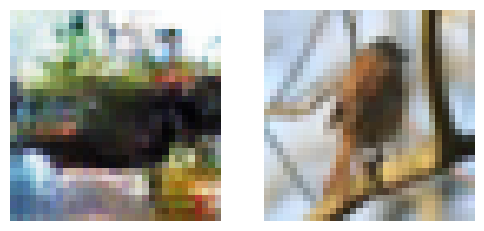

In [ ]:
gen_comparison(dc_replay_generator)